In [2]:
import os
import re
from collections import defaultdict, Counter
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import polars as pl
import loguru as logger
import matplotlib

from settings.settings_analyze_efizz import Settings_ae
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.rayleigh.load_rayleigh import collect_all_rayleigh_paths, load_all_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_compartment_values, extract_firing_rates
from behave_analysis.utils.creating_directories import make_directory
from settings.settings_analyze_efizz import Settings_ae as Settings
from behave_analysis.analyze.TunED.model import TunEdModel

from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

In [3]:
experiments_objects = [JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

tinny_barrier = [JAL8_tiny_3may, JAL8_21may, JAL7_30apr]

# Mice groups based on session names
mice_groups = {
    "JAL6": ['JAL6_flip7_1apr', 'JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_flip5_22mar', 'JAL7_flip2_12mar', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', 'JAL8_14may'],
    "JAL4": ['JAL4_3rdSept', 'JAL4_19thSept', 'JAL4_28aug', 'JAL4_11thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept']}


session_NAMES = ["JAL6_flip7_1apr", "JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar",
                 "JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept", 
                 "JAL005_8thSept", "JAL005_21stSept",
                 "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_23apr",
                 "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_14may",
                 "JAL4_3rdSept", "JAL4_19thSept", "JAL4_28aug", "JAL4_11thSept"]

# Store the cell ids in a session -> cluster id -> top two rayleigh values + other thresholds ready for the tuned model

In [4]:
# New code that stores the top two rayleigh angles for each session and cell angle combo and sets a threshold for firing rates

In [5]:
def regex(angle):
    "Remove unwanted characters from angle file string"
    pattern = r'^(.*?)(?=_Rayleigh)'
    match = re.search(pattern, angle)
    assert match, f"Could not find match for {angle}"
    return match.group(0)

def nest_dic():
    """A function to create arbitrarily nested dictionaries"""
    return defaultdict(nest_dic)

In [6]:
# Init Params
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
dir = make_directory(r"Z:\Jasmine_Laurence\rayleigh_analysis")
angle_keys = ['hdir_Rayleigh.arrow', 'hsa_Rayleigh.arrow', 'h_postflipbar_a_Rayleigh.arrow', 'h_preflipbar_a_Rayleigh.arrow']

In [9]:
from collections import defaultdict
import os
import numpy as np
import pandas as pd

def build_threat_dict_max_rayleigh(
    experiments_objects,
    session_names,
    conditions,
    angle_keys,
    rayleigh_threshold=0.25,
    fr_threshold=2.0,
):
    """
    Recreates your per-session sweep loop as a function (no global state).
    Returns:
        threat_dict_max_rayleigh : dict[session_name][cluster_id][condition] -> [(angle,label_rayleigh), (angle,label_rayleigh)] | "Not tuned"
        stats : dict with {'not_meet_threshold': int, 'cell_count': int, 'skipped_sessions': list}
    Assumes the following helper functions/objects exist in scope:
        - get_experiment(session)
        - collect_all_rayleigh_paths(session, cluster_type="good", conditions=...)
        - load_all_rayleigh_data(paths)
        - extract_firing_rates(condition_data[cond][angle])
        - extract_compartment_values(condition_data[cond][angle], column_name="Rayleigh")
        - regex(angle)
        - Each loaded_session has attributes: base_path, processed_path
    """

    threat_dict_max_rayleigh = nest_dic()  # dict[session][cell][condition] = {max_rayleigh_angle}
    not_meet_threshold = 0
    cell_count = 0
    skipped_sessions = []

    for i, session in enumerate(experiments_objects):
        print(f"Processing session {i+1}/{len(experiments_objects)}: {session}")
        loaded_session = get_experiment(session)
        paths = collect_all_rayleigh_paths(session=loaded_session, cluster_type="good", conditions=conditions)  # paths[condition][angles]
        condition_data = load_all_rayleigh_data(paths)  # condition_data[condition][angles]

        # Load cluster master
        try:
            cluster_master = pd.read_csv(
                os.path.join(loaded_session.base_path, loaded_session.processed_path, "spike_count_by_frame_and_goodcluster.csv")
            )
        except Exception:
            print(f"Could not load cluster master for session {session}")
            skipped_sessions.append(session)
            continue

        spike_clusters = sorted(cluster_master['spike_clusters'].unique())

        # If no data for shelter_only, skip
        if len(condition_data["shelter_only"].keys()) == 0:
            print(f"Skipping session {session} as no data found")
            skipped_sessions.append(session)
            continue

        # Cells are same across conditions/angles in a session
        nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"])
        assert nCells == len(spike_clusters), f"Number of cells {nCells} does not match number of clusters {len(spike_clusters)}"
        cell_count += nCells

        for cell in range(nCells):
            tuned_across_conditions = False

            for ci, condition in enumerate(condition_data.keys()):
                rayleigh_list = []
                angle_list = []
                tuned = False  # tuned to any angle in this condition
                rayleigh = 0   # per-condition max Rayleigh

                for angle in angle_keys:
                    sz_fr, tz_fr = extract_firing_rates(condition_data[condition][angle])
                    cell_fr = tz_fr[cell]  # threat-zone firing rate only

                    # Extract Rayleigh (threat-only) for this angle
                    output = extract_compartment_values(condition_data[condition][angle], column_name="Rayleigh")

                    if (
                        (output[cell][1] > rayleigh)             # larger than current max
                        and (output[cell][1] > rayleigh_threshold) # above Rayleigh threshold
                        and (max(cell_fr) > fr_threshold)          # above FR threshold
                    ):
                        rayleigh = output[cell][1]
                        tuned = True
                        tuned_across_conditions = True

                    if output[cell][1] > rayleigh_threshold:
                        rayleigh_list.append(output[cell][1])
                        angle_list.append(regex(angle))

                # Top two Rayleighs (by threshold-filtered list)
                top_indices = np.argsort(rayleigh_list)[-2:]   # indices of two largest values
                top_angles = [angle_list[idx] for idx in top_indices]

                # Save per-cell, per-condition result
                sess_name = session_names[i]
                if tuned and len(rayleigh_list) == 2:
                    threat_dict_max_rayleigh[sess_name][spike_clusters[cell]][condition] = [
                        (top_angles[0], rayleigh_list[top_indices[0]]),
                        (top_angles[1], rayleigh_list[top_indices[1]]),
                    ]
                else:
                    threat_dict_max_rayleigh[sess_name][spike_clusters[cell]][condition] = "Not tuned"

            if not tuned_across_conditions:
                not_meet_threshold += 1

    stats = {
        "not_meet_threshold": not_meet_threshold,
        "cell_count": cell_count,
        "skipped_sessions": skipped_sessions,
    }

    # Save the threat dict as a pickle file
    with open(os.path.join(dir, "threat_dict_top2_angles_per_condition_max_ray.pkl"), "wb") as f:
        pickle.dump(threat_dict_max_rayleigh, f)
    
    return threat_dict_max_rayleigh, stats

In [10]:
build_threat_dict_max_rayleigh(
    experiments_objects=experiments_objects,
    session_names=session_NAMES,
    conditions=conditions,
    angle_keys=angle_keys,
    rayleigh_threshold=0.25,
    fr_threshold=2.0,
)

Processing session 1/24: Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, root_path=WindowsPath('JAL006'), experiment_name='flip', experiment_idx=7, experiment_date='2024_04_01', experiment_time='11_24_46', experiment_path=WindowsPath('JAL006_shelter_barrier_flip_7_take2_2024_04_01T11_24_46'), shelter_time=[0, -1], barrier_time=[77, -1], barrier_flip_time=189.25)
Processing session 2/24: Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, root_path=WindowsPath('JAL006'), experiment_name='flip', experiment_idx=3, experiment_date='2024_03_18', experiment_time='11_53_29', experiment_path=WindowsPath('JAL006_barrier_flip2_2024_03_18T11_53_29'), shelter_time=[0.25, -1], barrier_time=[68.25, -1], barrier_flip_time=180.25)
Could not load cluster master for session Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, 

(defaultdict(<function __main__.nest_dic()>,
             {'JAL6_flip7_1apr': defaultdict(<function __main__.nest_dic()>,
                          {5: defaultdict(<function __main__.nest_dic()>,
                                       {'shelter_only': 'Not tuned',
                                        'barrier_pre_flip': 'Not tuned',
                                        'barrier_post_flip': 'Not tuned'}),
                           6: defaultdict(<function __main__.nest_dic()>,
                                       {'shelter_only': 'Not tuned',
                                        'barrier_pre_flip': 'Not tuned',
                                        'barrier_post_flip': 'Not tuned'}),
                           7: defaultdict(<function __main__.nest_dic()>,
                                       {'shelter_only': 'Not tuned',
                                        'barrier_pre_flip': [('hsa',
                                          0.26048892909102805),
                  

# Load a single rayleigh threshold example - only accepts max rayleigh if two angles meet the crieteria, logic is wrong

In [11]:
# open the pickle file
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition_max_ray.pkl"), "rb") as f:
    single_example_loaded_threat_dict_max_rayleigh = pickle.load(f)

Plot the single rayleigh threshold example

doing a wilcoxon test
doing a wilcoxon test


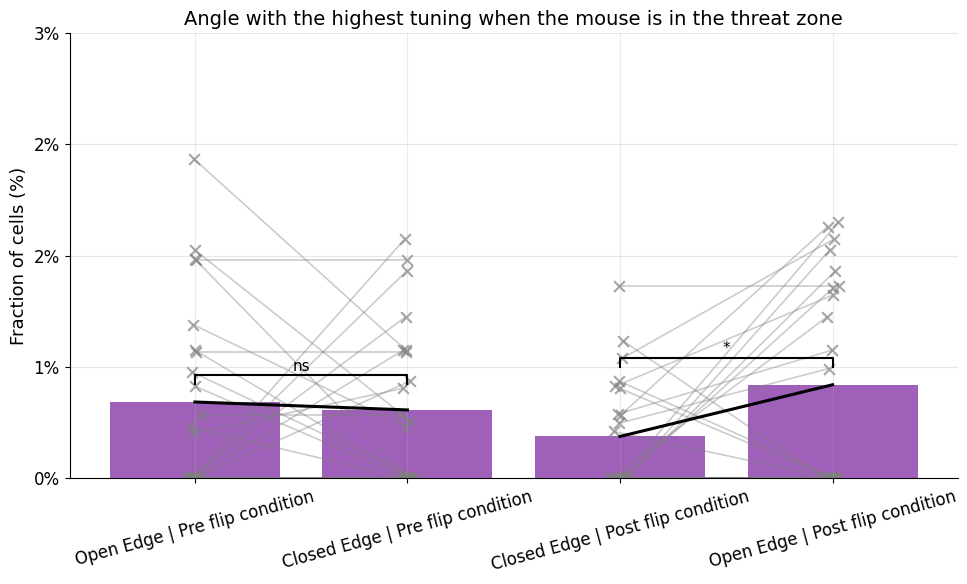

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


p (Open vs Closed Pre) : 0.7535516091563128
p (Closed vs Open Post): 0.03546470751403722


(             session          condition  total_cells  h_preflipbar_a_count  \
 0    JAL6_flip7_1apr   barrier_pre_flip          271                     4   
 1    JAL6_flip7_1apr  barrier_post_flip          271                     1   
 2   JAL6_flip5_25mar   barrier_pre_flip          116                     0   
 3   JAL6_flip5_25mar  barrier_post_flip          116                     0   
 4         JAL6_28mar   barrier_pre_flip          124                     0   
 5         JAL6_28mar  barrier_post_flip          124                     1   
 6         JAL3_25aug   barrier_pre_flip          100                     0   
 7         JAL3_25aug  barrier_post_flip          100                     0   
 8         JAL3_1sept   barrier_pre_flip           92                     0   
 9         JAL3_1sept  barrier_post_flip           92                     0   
 10        JAL3_4sept   barrier_pre_flip           57                     0   
 11        JAL3_4sept  barrier_post_flip           5

In [39]:
%matplotlib inline
def plot_pair_fractions_from_threat_dict(single_example_loaded_threat_dict_max_rayleigh):
    """
    Build per-session summary, draw the dynamic % plot with paired Wilcoxon stats,
    and return the session_summary_df and p-values.

    Returns
    -------
    session_summary_df : pd.DataFrame
    p_pre : float
    p_post : float
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
    from scipy.stats import wilcoxon

    # --- 1) Build per-session summary -------------------------------------------
    target_conditions = ["barrier_pre_flip", "barrier_post_flip"]
    angle_labels_of_interest = ["h_preflipbar_a", "h_postflipbar_a"]

    # counts_by_session[session][condition] -> dict of totals and angle counts
    counts_by_session = {}

    for session, cell_dict in single_example_loaded_threat_dict_max_rayleigh.items():
        if session not in counts_by_session:
            counts_by_session[session] = {
                c: {"total_cells": 0,
                    "tuned_cells": 0,
                    "h_preflipbar_a": 0,
                    "h_postflipbar_a": 0}
                for c in target_conditions
            }
        for cluster_id, cond_dict in cell_dict.items():
            for cond in target_conditions:
                if cond not in cond_dict:
                    continue
                counts_by_session[session][cond]["total_cells"] += 1
                entry = cond_dict[cond]

                if entry == "Not tuned" or entry is None:
                    continue
                if not isinstance(entry, (list, tuple)) or len(entry) == 0:
                    continue

                try:
                    max_angle, _ = max(entry, key=lambda x: x[1])
                except Exception:
                    continue

                counts_by_session[session][cond]["tuned_cells"] += 1
                if max_angle in angle_labels_of_interest:
                    counts_by_session[session][cond][max_angle] += 1

    # Build per-session rows
    session_rows = []
    for session, conds in counts_by_session.items():
        for cond, c in conds.items():
            tot = c["total_cells"] if c["total_cells"] else 0
            pre_n  = c["h_preflipbar_a"]
            post_n = c["h_postflipbar_a"]
            session_rows.append({
                "session": session,
                "condition": cond,
                "total_cells": tot,
                "h_preflipbar_a_count": pre_n,
                "h_postflipbar_a_count": post_n,
                "pct_pre_over_total":  (pre_n  / tot) if tot else 0.0,
                "pct_post_over_total": (post_n / tot) if tot else 0.0
            })

    session_summary_df = pd.DataFrame(session_rows)

    # --- 2) Compute group means for the four bars (unweighted mean across sessions)
    def mean_or_zero(s):
        return float(s.mean()) if len(s) else 0.0

    # slot mapping:
    # 0 Open Edge | Pre flip        -> barrier_pre_flip,  pct_pre_over_total
    # 1 Closed Edge | Pre flip      -> barrier_pre_flip,  pct_post_over_total
    # 2 Closed Edge | Post flip     -> barrier_post_flip, pct_pre_over_total
    # 3 Open Edge | Post flip       -> barrier_post_flip, pct_post_over_total
    bar_means = [
        mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_pre_over_total"]),
        mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_post_over_total"]),
        mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_pre_over_total"]),
        mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_post_over_total"]),
    ]

    # --- 3) Dynamic percent plot with per-session scatter & pair-only significance bars ----
    x_labels = [
        'Open Edge | Pre flip condition',
        'Closed Edge | Pre flip condition',
        'Closed Edge | Post flip condition',
        'Open Edge | Post flip condition'
    ]
    x = np.arange(4)

    # Collect per-session values (fractions) for later significance (simple Wilcoxon if SciPy)
    open_pre_vals   = []
    closed_pre_vals = []
    closed_post_vals= []
    open_post_vals  = []

    rng = np.random.default_rng(7)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x, bar_means, color='#8e44ad', alpha=0.85)

    all_session_vals = []
    for session in session_summary_df["session"].unique():
        sub = session_summary_df[session_summary_df["session"] == session]
        def pull(cond, col):
            v = sub.loc[sub["condition"]==cond, col]
            return float(v.iloc[0]) if len(v) else np.nan
        y0 = pull("barrier_pre_flip",  "pct_pre_over_total")   # open pre
        y1 = pull("barrier_pre_flip",  "pct_post_over_total")  # closed pre
        y2 = pull("barrier_post_flip", "pct_pre_over_total")   # closed post
        y3 = pull("barrier_post_flip", "pct_post_over_total")  # open post

        xs = x + rng.normal(0, 0.02, size=4)
        ys = np.array([y0, y1, y2, y3], dtype=float)
        all_session_vals.extend(ys[np.isfinite(ys)].tolist())

        ax.scatter(xs, ys, marker='x', s=60, linewidths=1.5, color='gray', alpha=0.7)
        if np.isfinite(y0) and np.isfinite(y1):
            ax.plot([xs[0], xs[1]], [y0, y1], color='gray', alpha=0.4, linewidth=1.2)
            open_pre_vals.append(y0); closed_pre_vals.append(y1)
        if np.isfinite(y2) and np.isfinite(y3):
            ax.plot([xs[2], xs[3]], [y2, y3], color='gray', alpha=0.4, linewidth=1.2)
            closed_post_vals.append(y2); open_post_vals.append(y3)

    # Bold mean pair connectors
    ax.plot([x[0], x[1]], [bar_means[0], bar_means[1]], color='black', linewidth=2.2)
    ax.plot([x[2], x[3]], [bar_means[2], bar_means[3]], color='black', linewidth=2.2)

    # Dynamic y limit (fractions)
    vals_for_limit = np.array(bar_means + all_session_vals, dtype=float)
    vals_for_limit = vals_for_limit[np.isfinite(vals_for_limit)]
    ymax = float(vals_for_limit.max()) if vals_for_limit.size else 0.05
    y_top = max(0.03, ymax * 1.35)
    if y_top > 0.25:
        y_top = min(y_top, 0.25)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.set_ylim(0, y_top)
    ticks = np.linspace(0, y_top, 6 if y_top >= 0.05 else 5)
    ax.set_yticks(ticks)

    ax.set_ylabel('Fraction of cells (%)', fontsize=13)
    ax.set_title('Angle with the highest tuning when the mouse is in the threat zone', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=15)
    ax.grid(axis='y', alpha=0.3)

    # --- 4) Significance (pair-only) ------------------------------------------------
    def p_val(a,b):
        a=np.asarray(a); b=np.asarray(b)
        if len(a)<3 or len(a)!=len(b): return np.nan
        if np.allclose(a,b): return 1.0
        print("doing a wilcoxon test")
        return wilcoxon(a,b,zero_method='wilcox',alternative='two-sided',mode='auto')[1]

    p_pre  = p_val(open_pre_vals, closed_pre_vals)
    p_post = p_val(open_post_vals, closed_post_vals)

    def stars(p):
        if np.isnan(p): return "n/a"
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"

    def add_sig_bar(ax, x1, x2, top_y, p_val, frac_pad):
        lab = stars(p_val)
        y = top_y + frac_pad
        ax.plot([x1, x1, x2, x2], [y, y+frac_pad*0.5, y+frac_pad*0.5, y], lw=1.5, color='k')
        ax.text((x1 + x2)/2, y + frac_pad*0.6, lab, ha='center', va='bottom', fontsize=11)

    pad = 0.04 * y_top
    add_sig_bar(ax, 0, 1, max(bar_means[0], bar_means[1]), p_pre,  pad)
    add_sig_bar(ax, 2, 3, max(bar_means[2], bar_means[3]), p_post, pad)

    plt.tight_layout()
    plt.show()

    print("p (Open vs Closed Pre) :", p_pre)
    print("p (Closed vs Open Post):", p_post)

    #save figure
    fig.savefig(os.path.join(dir, "top2_max_rayleigh_dynamic_percent_plot.eps"), dpi=300)

    return session_summary_df, p_pre, p_post

plot_pair_fractions_from_threat_dict(single_example_loaded_threat_dict_max_rayleigh)

# Only accept cells that are tuned wehn fr is also max with max rayleigh

In [ ]:

threat_dict_max_fr = nest_dic() # dict[session][cell][condition] = {max_rayleigh_angle}
cell_count = 0
not_meet_threshold = 0

for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session=loaded_session, cluster_type="good", conditions=conditions)
    condition_data = load_all_rayleigh_data(paths)  # condition_data[condition][angle_key]

    try:
        cluster_master = pd.read_csv(
            os.path.join(loaded_session.base_path, loaded_session.processed_path, "spike_count_by_frame_and_goodcluster.csv")
        )
    except Exception as e:
        print(f"Could not load cluster master for session {session}: {e}")
        continue

    spike_clusters = sorted(cluster_master['spike_clusters'].unique())

    # If no data for this session, skip
    if len(condition_data["shelter_only"].keys()) == 0:
        print(f"Skipping session {session} as no data found")
        continue

    # Cells are consistent across angles/conditions within a session
    nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"])
    assert nCells == len(spike_clusters), f"Number of cells {nCells} != number of clusters {len(spike_clusters)}"
    cell_count += nCells

    for cell in range(nCells):
        tuned_across_conditions = False

        for condition in condition_data.keys():
            # Collect per-angle metrics for this cell & condition
            angle_names = []
            rayleigh_vals = []
            fr_vals = []

            for angle_key in angle_keys:
                # Firing rates for this angle/condition
                sz_fr, tz_fr = extract_firing_rates(condition_data[condition][angle_key])
                cell_fr = tz_fr[cell]  # FR in threat zone for this cell (array or scalar)
                # Reduce FR to a scalar metric (peak); works if array or scalar
                try:
                    fr_val = float(np.max(cell_fr))
                except Exception:
                    fr_val = float(cell_fr)

                # Rayleigh (threat-only; index 1 per your convention)
                rayleigh_arr = extract_compartment_values(
                    condition_data[condition][angle_key], column_name="Rayleigh"
                )
                rl = float(rayleigh_arr[cell][1])

                angle_names.append(regex(angle_key))
                rayleigh_vals.append(rl)
                fr_vals.append(fr_val)

            angle_names = np.array(angle_names, dtype=object)
            rayleigh_vals = np.array(rayleigh_vals, dtype=float)
            fr_vals = np.array(fr_vals, dtype=float)

            # Find angle(s) with the highest firing rate for this condition & cell
            if np.all(~np.isfinite(fr_vals)):
                # No valid FRs; mark not tuned
                threat_dict_max_fr[session_NAMES[i]][spike_clusters[cell]][condition] = "Not tuned"
                continue

            fr_max = np.nanmax(fr_vals)
            fr_winner_mask = np.isclose(fr_vals, fr_max, rtol=0, atol=1e-9)

            # Apply thresholds + require angle to be an FR winner
            keep_mask = (
                (rayleigh_vals > rayleigh_threshold) &
                (fr_vals > fr_threshold) &
                fr_winner_mask
            )

            if not np.any(keep_mask):
                # No angles pass both Rayleigh/FR thresholds AND are FR winners
                threat_dict_max_fr[session_NAMES[i]][spike_clusters[cell]][condition] = "Not tuned"
                continue

            # Among those that pass, take up to the top-2 by Rayleigh (ties handled naturally)
            passing_indices = np.where(keep_mask)[0]
            order = np.argsort(rayleigh_vals[passing_indices])[::-1]  # descending Rayleigh
            top_indices = passing_indices[order[:2]]

            # Save (angle, rayleigh) pairs
            top_list = [(angle_names[idx], float(rayleigh_vals[idx])) for idx in top_indices]
            threat_dict_max_fr[session_NAMES[i]][spike_clusters[cell]][condition] = top_list
            tuned_across_conditions = True

        if not tuned_across_conditions:
            not_meet_threshold += 1


In [ ]:
# save the threat dict fr as a pickle file
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition_max_fr.pkl"), "wb") as f:
    pickle.dump(threat_dict_max_fr, f)

In [ ]:
# load the pickle file
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition_max_fr.pkl"), "rb") as f:
    loaded_threat_dict_max_fr = pickle.load(f)

In [ ]:
# Combined: build per-session summary + dynamic % plot (pair significance bars only)
%matplotlib inline
from matplotlib.ticker import FuncFormatter

# --- 1) Build per-session summary -------------------------------------------
target_conditions = ["barrier_pre_flip", "barrier_post_flip"]
angle_labels_of_interest = ["h_preflipbar_a", "h_postflipbar_a"]

# counts_by_session[session][condition] -> dict of totals and angle counts
counts_by_session = {}

for session, cell_dict in loaded_threat_dict_max_fr.items():
    if session not in counts_by_session:
        counts_by_session[session] = {
            c: {"total_cells": 0,
                "tuned_cells": 0,
                "h_preflipbar_a": 0,
                "h_postflipbar_a": 0}
            for c in target_conditions
        }
    for cluster_id, cond_dict in cell_dict.items():
        for cond in target_conditions:
            if cond not in cond_dict:
                continue
            counts_by_session[session][cond]["total_cells"] += 1
            entry = cond_dict[cond]

            if entry == "Not tuned" or entry is None:
                continue
            if not isinstance(entry, (list, tuple)) or len(entry) == 0:
                continue

            try:
                max_angle, _ = max(entry, key=lambda x: x[1])
            except Exception:
                continue

            counts_by_session[session][cond]["tuned_cells"] += 1
            if max_angle in angle_labels_of_interest:
                counts_by_session[session][cond][max_angle] += 1

# Build per-session rows
session_rows = []
for session, conds in counts_by_session.items():
    for cond, c in conds.items():
        tot = c["total_cells"] if c["total_cells"] else 0
        pre_n  = c["h_preflipbar_a"]
        post_n = c["h_postflipbar_a"]
        session_rows.append({
            "session": session,
            "condition": cond,
            "total_cells": tot,
            "h_preflipbar_a_count": pre_n,
            "h_postflipbar_a_count": post_n,
            "pct_pre_over_total":  (pre_n  / tot) if tot else 0.0,
            "pct_post_over_total": (post_n / tot) if tot else 0.0
        })

session_summary_df = pd.DataFrame(session_rows)

# --- 2) Compute group means for the four bars (unweighted mean across sessions)
def mean_or_zero(s):
    return float(s.mean()) if len(s) else 0.0

# slot mapping:
# 0 Open Edge | Pre flip        -> barrier_pre_flip,  pct_pre_over_total
# 1 Closed Edge | Pre flip      -> barrier_pre_flip,  pct_post_over_total
# 2 Closed Edge | Post flip     -> barrier_post_flip, pct_pre_over_total
# 3 Open Edge | Post flip       -> barrier_post_flip, pct_post_over_total
bar_means = [
    mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_pre_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_post_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_pre_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_post_over_total"]),
]

# --- 3) Dynamic percent plot with per-session scatter & pair-only significance bars ----
x_labels = [
    'Open Edge | Pre flip condition',
    'Closed Edge | Pre flip condition',
    'Closed Edge | Post flip condition',
    'Open Edge | Post flip condition'
]
x = np.arange(4)

# Collect per-session values (fractions) for later significance (simple Wilcoxon if SciPy)
open_pre_vals   = []
closed_pre_vals = []
closed_post_vals= []
open_post_vals  = []

rng = np.random.default_rng(7)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, bar_means, color='#8e44ad', alpha=0.85)

all_session_vals = []
for session in session_summary_df["session"].unique():
    sub = session_summary_df[session_summary_df["session"] == session]
    def pull(cond, col):
        v = sub.loc[sub["condition"]==cond, col]
        return float(v.iloc[0]) if len(v) else np.nan
    y0 = pull("barrier_pre_flip",  "pct_pre_over_total")   # open pre
    y1 = pull("barrier_pre_flip",  "pct_post_over_total")  # closed pre
    y2 = pull("barrier_post_flip", "pct_pre_over_total")   # closed post
    y3 = pull("barrier_post_flip", "pct_post_over_total")  # open post

    xs = x + rng.normal(0, 0.02, size=4)
    ys = np.array([y0, y1, y2, y3], dtype=float)
    all_session_vals.extend(ys[np.isfinite(ys)].tolist())

    ax.scatter(xs, ys, marker='x', s=60, linewidths=1.5, color='gray', alpha=0.7)
    if np.isfinite(y0) and np.isfinite(y1):
        ax.plot([xs[0], xs[1]], [y0, y1], color='gray', alpha=0.4, linewidth=1.2)
        open_pre_vals.append(y0); closed_pre_vals.append(y1)
    if np.isfinite(y2) and np.isfinite(y3):
        ax.plot([xs[2], xs[3]], [y2, y3], color='gray', alpha=0.4, linewidth=1.2)
        closed_post_vals.append(y2); open_post_vals.append(y3)

# Bold mean pair connectors
ax.plot([x[0], x[1]], [bar_means[0], bar_means[1]], color='black', linewidth=2.2)
ax.plot([x[2], x[3]], [bar_means[2], bar_means[3]], color='black', linewidth=2.2)

# Dynamic y limit (fractions)
vals_for_limit = np.array(bar_means + all_session_vals, dtype=float)
vals_for_limit = vals_for_limit[np.isfinite(vals_for_limit)]
ymax = float(vals_for_limit.max()) if vals_for_limit.size else 0.05
y_top = max(0.03, ymax * 1.35)
if y_top > 0.25:
    y_top = min(y_top, 0.25)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.set_ylim(0, y_top)
ticks = np.linspace(0, y_top, 6 if y_top >= 0.05 else 5)
ax.set_yticks(ticks)

ax.set_ylabel('Fraction of cells (%)', fontsize=13)
ax.set_title('Angle with the highest firing rate, and then tuning when the mouse is in the threat zone', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=15)
ax.grid(axis='y', alpha=0.3)

# --- 4) Significance (pair-only) ------------------------------------------------
from scipy.stats import wilcoxon
def p_val(a,b):
    a=np.asarray(a); b=np.asarray(b)
    if len(a)<3 or len(a)!=len(b): return np.nan
    if np.allclose(a,b): return 1.0
    print("doing a wilcoxon test")
    return wilcoxon(a,b,zero_method='wilcox',alternative='two-sided',mode='auto')[1]

p_pre  = p_val(open_pre_vals, closed_pre_vals)
p_post = p_val(open_post_vals, closed_post_vals)

def stars(p):
    if np.isnan(p): return "n/a"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def add_sig_bar(ax, x1, x2, top_y, p_val, frac_pad):
    lab = stars(p_val)
    y = top_y + frac_pad
    ax.plot([x1, x1, x2, x2], [y, y+frac_pad*0.5, y+frac_pad*0.5, y], lw=1.5, color='k')
    ax.text((x1 + x2)/2, y + frac_pad*0.6, lab, ha='center', va='bottom', fontsize=11)

pad = 0.04 * y_top
add_sig_bar(ax, 0, 1, max(bar_means[0], bar_means[1]), p_pre,  pad)
add_sig_bar(ax, 2, 3, max(bar_means[2], bar_means[3]), p_post, pad)

plt.tight_layout()
plt.show()

print("p (Open vs Closed Pre) :", p_pre)
print("p (Closed vs Open Post):", p_post)

# vary the rayleigh threshold, and see what happens to the significant and change in the values bewteen the condiitons bars

In [ ]:
# === Rayleigh sweep → summary table ===========================================
import os
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.stats import wilcoxon

# --------------------------
# Init Params (kept as given)
# --------------------------
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
total_cells = 0
total_sessions = 0
fr_threshold = 2  # Hz
dir = make_directory(r"Z:\Jasmine_Laurence\rayleigh_analysis")
angle_keys = [
    'hdir_Rayleigh.arrow',
    'hsa_Rayleigh.arrow',
    'h_postflipbar_a_Rayleigh.arrow',
    'h_preflipbar_a_Rayleigh.arrow'
]
threat_dict_max_rayleigh = nest_dic()  # NOW: dict[rayleigh_thr][session][cell][condition] = ...
cell_count = 0
not_meet_threshold_total = 0

# Rayleigh thresholds to sweep
rayleigh_thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

# --------------------------
# Helper
# --------------------------
def safe_max_angle(entry):
    """
    entry is either "Not tuned" or a list like:
      [(angle_label, value), (angle_label, value)]
    Returns the angle_label with the max Rayleigh value, or None.
    """
    if entry == "Not tuned" or entry is None:
        return None
    if not isinstance(entry, (list, tuple)) or len(entry) == 0:
        return None
    try:
        return max(entry, key=lambda x: x[1])[0]
    except Exception:
        return None

def wilcoxon_paired(a, b):
    """
    Two-sided Wilcoxon paired p-value with safety checks.
    Requires at least 3 pairs; returns np.nan otherwise.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    if len(a) < 3 or len(a) != len(b):
        return np.nan
    if np.allclose(a, b):
        return 1.0
    return wilcoxon(a, b, zero_method='wilcox', alternative='two-sided', mode='auto')[1]

# --------------------------
# Main sweep: build dict per threshold
# --------------------------
for thr in rayleigh_thresholds:
    not_meet_threshold = 0

    for i, session in enumerate(experiments_objects):
        loaded_session = get_experiment(session)
        paths = collect_all_rayleigh_paths(session=loaded_session, cluster_type="good", conditions=conditions)  # paths[condition][angles]
        condition_data = load_all_rayleigh_data(paths)  # condition_data[condition][angle] -> dataframe/array

        try:
            cluster_master = pd.read_csv(
                os.path.join(loaded_session.base_path, loaded_session.processed_path, "spike_count_by_frame_and_goodcluster.csv")
            )
        except Exception as e:
            print(f"Could not load cluster master for session {session}: {e}")
            continue

        # extract unique spike cluster IDs
        spike_clusters = sorted(cluster_master['spike_clusters'].unique())

        # Skip if no data for shelter_only (used to infer nCells)
        if "shelter_only" not in condition_data or len(condition_data["shelter_only"].keys()) == 0:
            print(f"Skipping session {session} as no data found")
            continue

        # Cells count (assumed identical across conditions)
        try:
            nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"])
        except Exception:
            print(f"Could not read nCells for session {session}; skipping.")
            continue

        assert nCells == len(spike_clusters), f"Number of cells {nCells} != number of clusters {len(spike_clusters)}"
        cell_count += nCells

        for cell in range(nCells):
            tuned_across_conditions = False

            for ci, condition in enumerate(condition_data.keys()):
                rayleigh_list = []
                angle_list = []
                tuned = False
                rayleigh_best = 0.0  # best per condition (resets each condition)

                for angle in angle_keys:
                    # Firing rates (threat-zone only)
                    sz_fr, tz_fr = extract_firing_rates(condition_data[condition][angle])
                    cell_fr = tz_fr[cell]  # threat-zone FR only

                    # Rayleigh (threat-zone column)
                    output = extract_compartment_values(condition_data[condition][angle], column_name="Rayleigh")
                    cell_rayleigh = output[cell][1]  # index 1 = THREAT (as per your code)

                    if (
                        (cell_rayleigh > rayleigh_best) and
                        (cell_rayleigh > thr) and
                        (max(cell_fr) > fr_threshold)
                    ):
                        rayleigh_best = cell_rayleigh
                        max_angle_str = regex(angle)
                        tuned = True
                        tuned_across_conditions = True

                    if cell_rayleigh > thr:
                        rayleigh_list.append(cell_rayleigh)
                        angle_list.append(regex(angle))

                # top-2 by Rayleigh for this condition
                if len(rayleigh_list) >= 2:
                    top_idx = np.argsort(rayleigh_list)[-2:]
                    top_angles = [angle_list[idx] for idx in top_idx]
                    top_values = [rayleigh_list[idx] for idx in top_idx]
                    entry = list(zip(top_angles, top_values))
                elif tuned and len(rayleigh_list) == 1:
                    # Only one angle passes thr + FR; still store it (pad to 1)
                    entry = [(angle_list[0], rayleigh_list[0])]
                else:
                    entry = "Not tuned"

                # Save: dict[thr][session][cell_id][condition] = entry
                threat_dict_max_rayleigh[thr][session_NAMES[i]][spike_clusters[cell]][condition] = entry

            if not tuned_across_conditions:
                not_meet_threshold += 1

    not_meet_threshold_total += not_meet_threshold
    # (Optional) print per-threshold not-met count for debugging
    # print(f"thr={thr:.2f} -> cells not meeting thresholds: {not_meet_threshold}")

# --------------------------
# Build summary table across thresholds
# --------------------------
target_conditions = ["barrier_pre_flip", "barrier_post_flip"]
angle_labels_of_interest = ["h_preflipbar_a", "h_postflipbar_a"]  # open/closed mapping

rows = []

for thr in rayleigh_thresholds:
    loaded_threat_dict = threat_dict_max_rayleigh[thr]

    # counts_by_session[session][condition] = dict of totals + angle counts
    counts_by_session = {}
    for session, cell_dict in loaded_threat_dict.items():
        if session not in counts_by_session:
            counts_by_session[session] = {
                c: {"total_cells": 0,
                    "tuned_cells": 0,
                    "h_preflipbar_a": 0,
                    "h_postflipbar_a": 0}
                for c in target_conditions
            }

        for cluster_id, cond_dict in cell_dict.items():
            for cond in target_conditions:
                if cond not in cond_dict:
                    continue
                counts_by_session[session][cond]["total_cells"] += 1
                entry = cond_dict[cond]

                max_angle = safe_max_angle(entry)
                if max_angle is None:
                    continue

                counts_by_session[session][cond]["tuned_cells"] += 1
                if max_angle in angle_labels_of_interest:
                    counts_by_session[session][cond][max_angle] += 1

    # Per-session fractions for stats
    open_pre_vals, closed_pre_vals = [], []
    closed_post_vals, open_post_vals = [], []

    # Aggregate counts across sessions for the table's N columns
    open_pre_n = 0
    closed_pre_n = 0
    closed_post_n = 0
    open_post_n = 0
    total_cells_sum = 0  # total across sessions (pre condition totals)

    for session, conds in counts_by_session.items():
        # Pull totals
        pre_tot = conds["barrier_pre_flip"]["total_cells"]
        post_tot = conds["barrier_post_flip"]["total_cells"]
        # (They *should* match per session; we'll use pre for total_cells aggregation)
        total_cells_sum += pre_tot

        # Counts of angles under each condition
        pre_open  = conds["barrier_pre_flip"]["h_preflipbar_a"]   # "Open Edge | Pre flip"
        pre_closed= conds["barrier_pre_flip"]["h_postflipbar_a"]  # "Closed Edge | Pre flip"
        post_closed = conds["barrier_post_flip"]["h_preflipbar_a"]  # "Closed Edge | Post flip"
        post_open   = conds["barrier_post_flip"]["h_postflipbar_a"] # "Open Edge | Post flip"

        open_pre_n   += pre_open
        closed_pre_n += pre_closed
        closed_post_n+= post_closed
        open_post_n  += post_open

        # Fractions for Wilcoxon (paired per session)
        # guard divide-by-zero
        if pre_tot > 0:
            open_pre_vals.append(pre_open / pre_tot)
            closed_pre_vals.append(pre_closed / pre_tot)
        if post_tot > 0:
            closed_post_vals.append(post_closed / post_tot)
            open_post_vals.append(post_open / post_tot)

    # Group means (unweighted mean across sessions) for deltas
    def mean_or_nan(arr):
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        return float(arr.mean()) if arr.size else np.nan

    mean_open_pre    = mean_or_nan(open_pre_vals)
    mean_closed_pre  = mean_or_nan(closed_pre_vals)
    mean_closed_post = mean_or_nan(closed_post_vals)
    mean_open_post   = mean_or_nan(open_post_vals)

    delta_pre  = (mean_open_pre - mean_closed_pre) if np.isfinite(mean_open_pre) and np.isfinite(mean_closed_pre) else np.nan
    delta_post = (mean_closed_post - mean_open_post) if np.isfinite(mean_closed_post) and np.isfinite(mean_open_post) else np.nan

    p_pre  = wilcoxon_paired(open_pre_vals, closed_pre_vals)
    p_post = wilcoxon_paired(closed_post_vals, open_post_vals)

    rows.append({
        "rayleigh_threshold": thr,
        # raw counts across sessions
        "open_pre_n":   int(open_pre_n),
        "closed_pre_n": int(closed_pre_n),
        "closed_post_n":int(closed_post_n),
        "open_post_n":  int(open_post_n),
        "total_cells":  int(total_cells_sum),
        # deltas (difference of group means across sessions)
        "delta_pre_open_minus_closed": delta_pre,
        "p_pre_wilcoxon": p_pre,
        "delta_post_closed_minus_open": delta_post,
        "p_post_wilcoxon": p_post
    })

results_df = pd.DataFrame(rows).sort_values("rayleigh_threshold").reset_index(drop=True)

# Display and (optionally) save
pd.set_option('display.precision', 4)
print(results_df)

# Save to CSV next to your analysis dir
out_csv = os.path.join(dir, "rayleigh_threshold_sweep_summary.csv")
results_df.to_csv(out_csv, index=False)
print(f"\nSaved table to: {out_csv}")


In [16]:
# open the pickle file
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition_rayleigh_sweep.pkl"), "rb") as f:
    sweep_rayleigh = pickle.load(f)

   rayleigh_threshold  open_pre_n  closed_pre_n  closed_post_n  open_post_n  \
0                0.10         883           571            541          833   
1                0.15         619           388            369          570   
2                0.20         463           284            281          433   
3                0.25         370           224            222          346   
4                0.30         308           182            171          288   
5                0.35         241           136            141          231   
6                0.40         188           109            111          179   
7                0.45         152            89             87          141   
8                0.50         112            76             69          115   

   total_cells  delta_pre_open_minus_closed  p_pre_wilcoxon  \
0         4308                     0.067886        0.000254   
1         4308                     0.046153        0.000033   
2         4308      

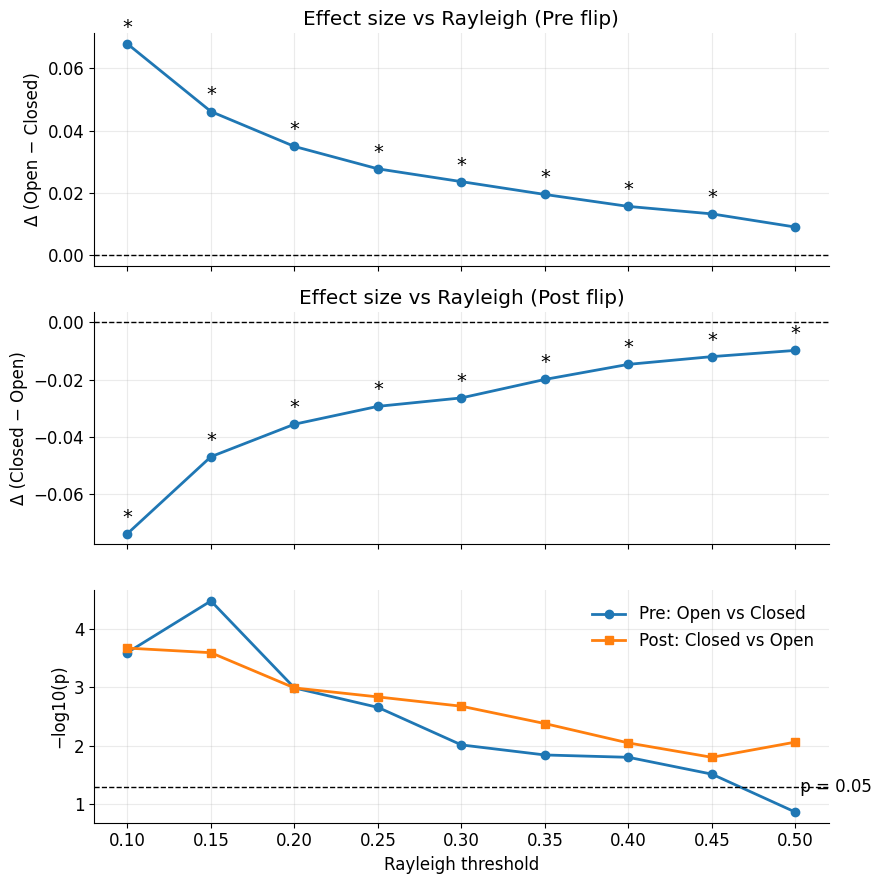

In [17]:
# === Rebuild per-session stats & redo Wilcoxon with strict session alignment ===
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import os

# --- Helper functions ---
def safe_max_angle(entry):
    if entry == "Not tuned" or entry is None:
        return None
    if not isinstance(entry, (list, tuple)) or len(entry) == 0:
        return None
    try:
        return max(entry, key=lambda x: x[1])[0]
    except Exception:
        return None

def mean_or_nan(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(arr.mean()) if arr.size else np.nan

def wilcoxon_strict(a_dict, b_dict):
    """
    Take dicts {session: value} and run Wilcoxon on intersection of sessions.
    """
    common = sorted(set(a_dict.keys()) & set(b_dict.keys()))
    if len(common) < 3:
        return np.nan
    a = np.array([a_dict[s] for s in common], dtype=float)
    b = np.array([b_dict[s] for s in common], dtype=float)
    if np.allclose(a, b):
        return 1.0
    return wilcoxon(a, b, zero_method='wilcox', alternative='two-sided', mode='auto')[1]

# --- Build strict stats from threat_dict_max_rayleigh ---
target_conditions = ["barrier_pre_flip", "barrier_post_flip"]
angle_labels_of_interest = ["h_preflipbar_a", "h_postflipbar_a"]

rows = []

for thr, sess_dict in sweep_rayleigh.items():
    # Collect per-session fractions
    open_pre_dict, closed_pre_dict = {}, {}
    closed_post_dict, open_post_dict = {}, {}

    # Aggregate counts
    open_pre_n = closed_pre_n = closed_post_n = open_post_n = total_cells_sum = 0

    for session, cell_dict in sess_dict.items():
        pre_tot = post_tot = 0
        pre_open = pre_closed = post_open = post_closed = 0

        for cluster_id, cond_dict in cell_dict.items():
            for cond in target_conditions:
                if cond not in cond_dict:
                    continue
                if cond == "barrier_pre_flip":
                    pre_tot += 1
                elif cond == "barrier_post_flip":
                    post_tot += 1

                entry = cond_dict[cond]
                max_angle = safe_max_angle(entry)
                if max_angle is None:
                    continue
                if cond == "barrier_pre_flip":
                    if max_angle == "h_preflipbar_a": pre_open  += 1
                    if max_angle == "h_postflipbar_a": pre_closed+= 1
                if cond == "barrier_post_flip":
                    if max_angle == "h_postflipbar_a": post_open  += 1
                    if max_angle == "h_preflipbar_a":  post_closed+= 1

        # Store per-session fractions
        if pre_tot > 0:
            open_pre_dict[session]   = pre_open  / pre_tot
            closed_pre_dict[session] = pre_closed/ pre_tot
        if post_tot > 0:
            closed_post_dict[session] = post_closed / post_tot
            open_post_dict[session]   = post_open   / post_tot

        # Update aggregate counts
        total_cells_sum += pre_tot
        open_pre_n    += pre_open
        closed_pre_n  += pre_closed
        closed_post_n += post_closed
        open_post_n   += post_open

    # Group means across sessions
    mean_open_pre    = mean_or_nan(list(open_pre_dict.values()))
    mean_closed_pre  = mean_or_nan(list(closed_pre_dict.values()))
    mean_closed_post = mean_or_nan(list(closed_post_dict.values()))
    mean_open_post   = mean_or_nan(list(open_post_dict.values()))

    delta_pre  = mean_open_pre - mean_closed_pre
    delta_post = mean_closed_post - mean_open_post

    # Strict Wilcoxon
    p_pre  = wilcoxon_strict(open_pre_dict, closed_pre_dict)
    p_post = wilcoxon_strict(closed_post_dict, open_post_dict)

    rows.append({
        "rayleigh_threshold": thr,
        "open_pre_n":    open_pre_n,
        "closed_pre_n":  closed_pre_n,
        "closed_post_n": closed_post_n,
        "open_post_n":   open_post_n,
        "total_cells":   total_cells_sum,
        "delta_pre_open_minus_closed":  delta_pre,
        "p_pre_wilcoxon":               p_pre,
        "delta_post_closed_minus_open": delta_post,
        "p_post_wilcoxon":              p_post
    })

results_strict_df = pd.DataFrame(rows).sort_values("rayleigh_threshold").reset_index(drop=True)

print(results_strict_df)

# --- Pretty figure ---
x = results_strict_df["rayleigh_threshold"].values
delta_pre  = results_strict_df["delta_pre_open_minus_closed"].values
delta_post = results_strict_df["delta_post_closed_minus_open"].values
p_pre  = results_strict_df["p_pre_wilcoxon"].values
p_post = results_strict_df["p_post_wilcoxon"].values

def safe_mlog10(p):
    p = np.array(p, dtype=float)
    m = np.full_like(p, np.nan, dtype=float)
    ok = np.isfinite(p) & (p > 0)
    m[ok] = -np.log10(p[ok])
    return m

mlog_pre, mlog_post = safe_mlog10(p_pre), safe_mlog10(p_post)
sig_line = -np.log10(0.05)

plt.rcParams.update({
    "figure.figsize": (9, 9),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 12
})

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# Pre flip delta
ax1.plot(x, delta_pre, marker='o', linewidth=2)
ax1.axhline(0, linestyle='--', color='black', linewidth=1)
ax1.set_ylabel("Δ (Open − Closed)")
ax1.set_title("Effect size vs Rayleigh (Pre flip)")
for xi, yi, p in zip(x, delta_pre, p_pre):
    if np.isfinite(p) and p < 0.05 and np.isfinite(yi):
        ax1.annotate("*", (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=14)

# Post flip delta
ax2.plot(x, delta_post, marker='o', linewidth=2)
ax2.axhline(0, linestyle='--', color='black', linewidth=1)
ax2.set_ylabel("Δ (Closed − Open)")
ax2.set_title("Effect size vs Rayleigh (Post flip)")
for xi, yi, p in zip(x, delta_post, p_post):
    if np.isfinite(p) and p < 0.05 and np.isfinite(yi):
        ax2.annotate("*", (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=14)

# Significance plot
ax3.plot(x, mlog_pre,  marker='o', linewidth=2, label="Pre: Open vs Closed")
ax3.plot(x, mlog_post, marker='s', linewidth=2, label="Post: Closed vs Open")
ax3.axhline(sig_line, linestyle='--', color='black', linewidth=1)
ax3.set_ylabel("−log10(p)")
ax3.set_xlabel("Rayleigh threshold")
ax3.text(x[-1], sig_line, " p = 0.05", va='center', ha='left')
ax3.legend(frameon=False)

plt.tight_layout()
plt.show()


   rayleigh_threshold  open_pre_n  closed_pre_n  closed_post_n  open_post_n  \
0                0.10         782           512            485          743   
1                0.15         549           355            335          506   
2                0.20         423           252            248          373   
3                0.25         338           203            197          303   
4                0.30         268           163            157          246   
5                0.35         199           118            118          196   
6                0.40         162            98             94          153   
7                0.45         125            80             77          120   
8                0.50          87            64             58           96   

   total_cells  sessions_used_pre  sessions_used_post  delta_pre_mean_diff  \
0         4308                 22                  22             0.055851   
1         4308                 22                  22

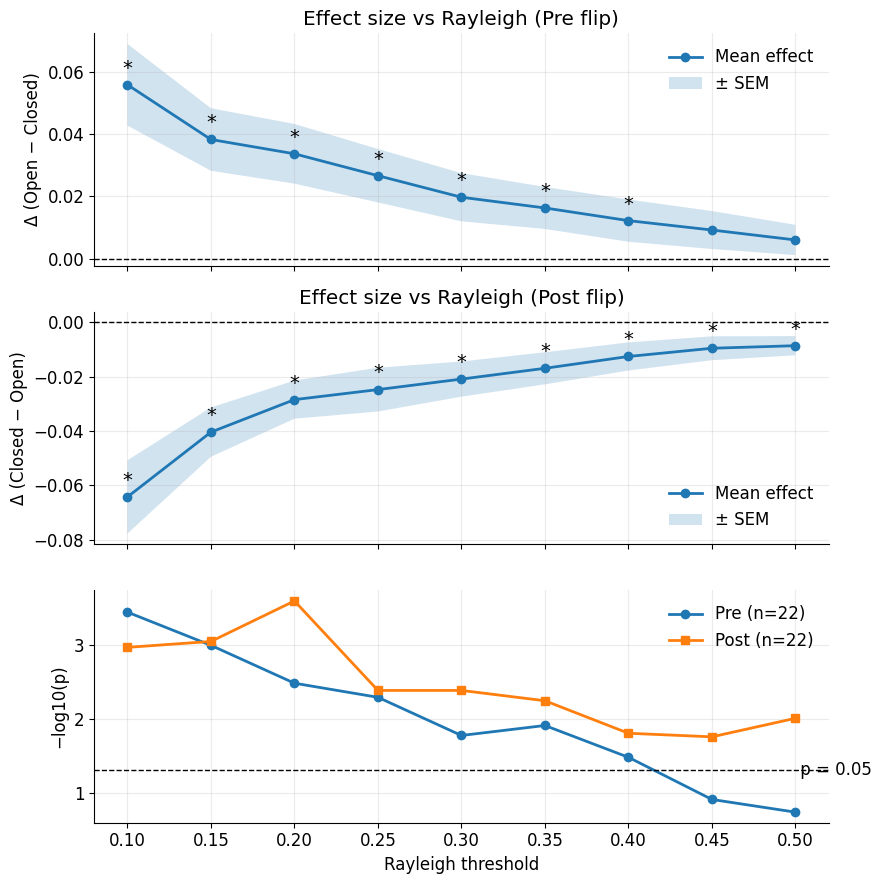

In [18]:
# === Recompute (exact-two rule), strict pairing, and plot mean ± SEM bands ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import os

# ----- Output dir -----
try:
    out_dir = dir  # from earlier cells
except NameError:
    out_dir = "."

# ----- Helpers -----
def keep_exact_two(entry):
    """Return max-angle label only if entry has exactly two (angle, value) tuples; else None."""
    if not isinstance(entry, (list, tuple)) or len(entry) != 2:
        return None
    try:
        return max(entry, key=lambda x: x[1])[0]
    except Exception:
        return None

def mean_sem(values):
    """Return mean and SEM for a 1D array-like (NaN if n<2)."""
    a = np.asarray(values, dtype=float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan, np.nan, 0
    if a.size == 1:
        return float(a.mean()), np.nan, 1
    return float(a.mean()), float(np.std(a, ddof=1)/np.sqrt(a.size)), int(a.size)

def wilcoxon_strict(dict_a, dict_b):
    """Paired Wilcoxon using intersection of session keys. Returns (p, n_pairs)"""
    common = sorted(set(dict_a) & set(dict_b))
    if len(common) < 3:
        return np.nan, len(common)
    a = np.array([dict_a[s] for s in common], dtype=float)
    b = np.array([dict_b[s] for s in common], dtype=float)
    if np.allclose(a, b):
        return 1.0, len(common)
    p = wilcoxon(a, b, zero_method='wilcox', alternative='two-sided', mode='auto')[1]
    return float(p), len(common)

def safe_mlog10(p):
    p = np.array(p, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)
    ok = np.isfinite(p) & (p > 0)
    out[ok] = -np.log10(p[ok])
    return out

# ----- Rebuild per-threshold per-session fractions (exact-two rule) -----
target_conditions = ["barrier_pre_flip", "barrier_post_flip"]

rows = []
thr_list = sorted(sweep_rayleigh.keys())

# Store per-threshold per-session paired diffs for SEM shading
pre_diffs_by_thr  = []  # each element: list of (open_pre - closed_pre) per-session
post_diffs_by_thr = []  # each element: list of (closed_post - open_post) per-session

for thr in thr_list:
    sess_dict = sweep_rayleigh[thr]

    # Per-session fractions
    open_pre, closed_pre = {}, {}
    closed_post, open_post = {}, {}

    # Aggregate counts across sessions for the N columns
    open_pre_n = closed_pre_n = closed_post_n = open_post_n = total_cells_sum = 0

    for session, cell_dict in sess_dict.items():
        pre_tot = post_tot = 0
        pre_open = pre_closed = post_open = post_closed = 0

        for cluster_id, cond_dict in cell_dict.items():
            # PRE
            if "barrier_pre_flip" in cond_dict:
                pre_tot += 1
                ang = keep_exact_two(cond_dict["barrier_pre_flip"])
                if ang == "h_preflipbar_a":   pre_open  += 1  # Open | Pre
                if ang == "h_postflipbar_a":  pre_closed += 1 # Closed | Pre
            # POST
            if "barrier_post_flip" in cond_dict:
                post_tot += 1
                ang = keep_exact_two(cond_dict["barrier_post_flip"])
                if ang == "h_preflipbar_a":   post_closed += 1 # Closed | Post
                if ang == "h_postflipbar_a":  post_open   += 1 # Open | Post

        if pre_tot > 0:
            open_pre[session]   = pre_open   / pre_tot
            closed_pre[session] = pre_closed / pre_tot
            total_cells_sum += pre_tot
            open_pre_n   += pre_open
            closed_pre_n += pre_closed

        if post_tot > 0:
            closed_post[session] = post_closed / post_tot
            open_post[session]   = post_open   / post_tot
            closed_post_n += post_closed
            open_post_n   += post_open

    # Strict paired diffs (per session) for SEM shading
    # Pre: (open - closed) within session
    pre_common  = sorted(set(open_pre) & set(closed_pre))
    pre_diffs   = [(open_pre[s] - closed_pre[s]) for s in pre_common]
    post_common = sorted(set(closed_post) & set(open_post))
    post_diffs  = [(closed_post[s] - open_post[s]) for s in post_common]

    pre_diffs_by_thr.append(pre_diffs)
    post_diffs_by_thr.append(post_diffs)

    # Means & SEMs for effect sizes (paired diffs)
    pre_mean,  pre_sem,  n_pre  = mean_sem(pre_diffs)
    post_mean, post_sem, n_post = mean_sem(post_diffs)

    # Paired Wilcoxon p-values on the same pairs
    p_pre,  n_pre_w  = wilcoxon_strict(open_pre, closed_pre)
    p_post, n_post_w = wilcoxon_strict(closed_post, open_post)

    rows.append({
        "rayleigh_threshold": thr,
        "open_pre_n":    int(open_pre_n),
        "closed_pre_n":  int(closed_pre_n),
        "closed_post_n": int(closed_post_n),
        "open_post_n":   int(open_post_n),
        "total_cells":   int(total_cells_sum),
        "sessions_used_pre":  int(n_pre),
        "sessions_used_post": int(n_post),
        "delta_pre_mean_diff":  pre_mean,     # mean of (open - closed) across sessions
        "sem_pre_mean_diff":    pre_sem,      # SEM across sessions
        "p_pre_wilcoxon":       p_pre,
        "delta_post_mean_diff": post_mean,    # mean of (closed - open) across sessions
        "sem_post_mean_diff":   post_sem,     # SEM across sessions
        "p_post_wilcoxon":      p_post
    })

results_sem_df = pd.DataFrame(rows).sort_values("rayleigh_threshold").reset_index(drop=True)
print(results_sem_df)

# Save updated table
csv_path = os.path.join(out_dir, "rayleigh_threshold_sweep_summary_exact2_withSEM.csv")
results_sem_df.to_csv(csv_path, index=False)
print(f"\nSaved table with SEM: {csv_path}")

# ----- Publication figure with shaded SEM bands -----
x = results_sem_df["rayleigh_threshold"].values

delta_pre  = results_sem_df["delta_pre_mean_diff"].values
sem_pre    = results_sem_df["sem_pre_mean_diff"].values
p_pre      = results_sem_df["p_pre_wilcoxon"].values

delta_post = results_sem_df["delta_post_mean_diff"].values
sem_post   = results_sem_df["sem_post_mean_diff"].values
p_post     = results_sem_df["p_post_wilcoxon"].values

mlog_pre, mlog_post = safe_mlog10(p_pre), safe_mlog10(p_post)
sig_line = -np.log10(0.05)

plt.rcParams.update({
    "figure.figsize": (9, 9),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 12
})

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)

# Panel 1: Pre flip (mean ± SEM of paired diffs)
ax1.plot(x, delta_pre, marker='o', linewidth=2, label="Mean effect")
ax1.fill_between(x, delta_pre - sem_pre, delta_pre + sem_pre, alpha=0.2, label="± SEM")
ax1.axhline(0, linestyle='--', linewidth=1, color='black')
ax1.set_title("Effect size vs Rayleigh (Pre flip)")
ax1.set_ylabel("Δ (Open − Closed)")
for xi, yi, p in zip(x, delta_pre, p_pre):
    if np.isfinite(p) and p < 0.05 and np.isfinite(yi):
        ax1.annotate("*", (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=14)
ax1.legend(frameon=False)

# Panel 2: Post flip (mean ± SEM of paired diffs)
ax2.plot(x, delta_post, marker='o', linewidth=2, label="Mean effect")
ax2.fill_between(x, delta_post - sem_post, delta_post + sem_post, alpha=0.2, label="± SEM")
ax2.axhline(0, linestyle='--', linewidth=1, color='black')
ax2.set_title("Effect size vs Rayleigh (Post flip)")
ax2.set_ylabel("Δ (Closed − Open)")
for xi, yi, p in zip(x, delta_post, p_post):
    if np.isfinite(p) and p < 0.05 and np.isfinite(yi):
        ax2.annotate("*", (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=14)
ax2.legend(frameon=False)

# Panel 3: Significance
ax3.plot(x, mlog_pre,  marker='o', linewidth=2, label=f"Pre (n={results_sem_df['sessions_used_pre'].max()})")
ax3.plot(x, mlog_post, marker='s', linewidth=2, label=f"Post (n={results_sem_df['sessions_used_post'].max()})")
ax3.axhline(sig_line, linestyle='--', linewidth=1, color='black')
ax3.set_ylabel("−log10(p)")
ax3.set_xlabel("Rayleigh threshold")
ax3.text(x[-1], sig_line, " p = 0.05", va='center', ha='left')
ax3.legend(frameon=False)

plt.tight_layout()

png_path = os.path.join(out_dir, "rayleigh_threshold_sweep_figure_exact2_withSEM.png")
pdf_path = os.path.join(out_dir, "rayleigh_threshold_sweep_figure_exact2_withSEM.pdf")
# fig.savefig(png_path, dpi=300, bbox_inches="tight")
# fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
# print(f"Saved figure with SEM:\n  {png_path}\n  {pdf_path}")

plt.show()


doing a wilcoxon test
doing a wilcoxon test


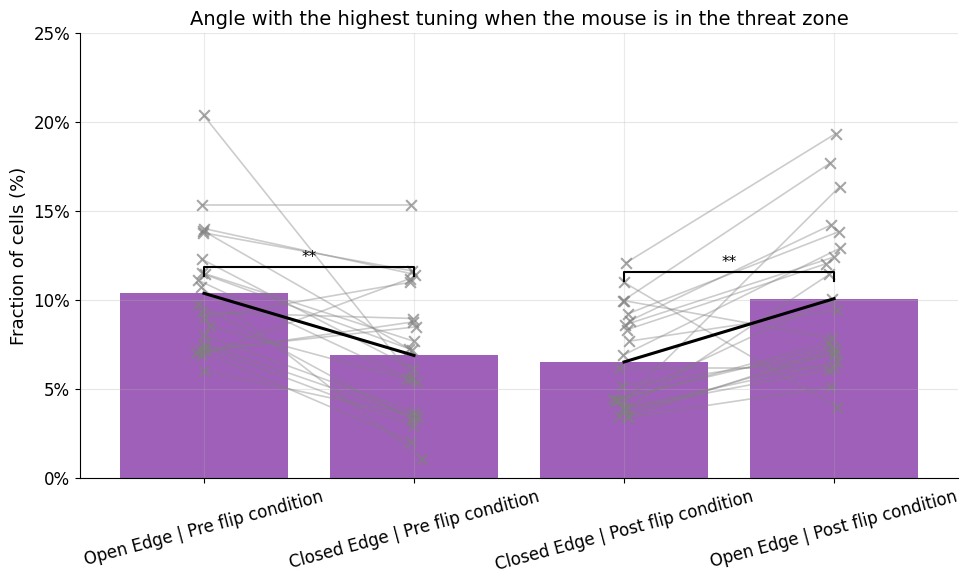

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


p (Open vs Closed Pre) : 0.0010212800218205383
p (Closed vs Open Post): 0.0010212800218205383


(             session          condition  total_cells  h_preflipbar_a_count  \
 0    JAL6_flip7_1apr   barrier_pre_flip          271                    38   
 1    JAL6_flip7_1apr  barrier_post_flip          271                    27   
 2   JAL6_flip5_25mar   barrier_pre_flip          116                     8   
 3   JAL6_flip5_25mar  barrier_post_flip          116                     5   
 4         JAL6_28mar   barrier_pre_flip          124                    19   
 5         JAL6_28mar  barrier_post_flip          124                    15   
 6         JAL3_25aug   barrier_pre_flip          100                     9   
 7         JAL3_25aug  barrier_post_flip          100                    11   
 8         JAL3_1sept   barrier_pre_flip           92                     9   
 9         JAL3_1sept  barrier_post_flip           92                     4   
 10        JAL3_4sept   barrier_pre_flip           57                     4   
 11        JAL3_4sept  barrier_post_flip           5

In [40]:
plot_pair_fractions_from_threat_dict(sweep_rayleigh[0.2])

In [41]:
def plot_rayleigh_sweep_exact2_sem(
    sweep_rayleigh,
    out_dir=".",
    save_table=False,
    save_fig=False,
    filename_prefix="rayleigh_threshold_sweep_exact2_withSEM"
):
    """
    Parameters
    ----------
    sweep_rayleigh : dict
        {threshold -> threat_dict}, where threat_dict[session][cluster_id][condition]
        is either "Not tuned"/None or a list of exactly two (angle_label, value) tuples.
    out_dir : str
        Where to save outputs if save_* is True.
    save_table : bool
        Save the summary CSV.
    save_fig : bool
        Save PNG and PDF of the figure.
    filename_prefix : str
        Base filename for saved outputs.

    Returns
    -------
    results_sem_df : pd.DataFrame
    (fig, (ax1,ax2,ax3)) : matplotlib objects
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from scipy.stats import wilcoxon
    import os

    # ---------- Helpers ----------
    def keep_exact_two(entry):
        """Return max-angle label only if entry has exactly two (angle, value) tuples; else None."""
        if not isinstance(entry, (list, tuple)) or len(entry) != 2:
            return None
        try:
            return max(entry, key=lambda x: x[1])[0]
        except Exception:
            return None

    def mean_sem(values):
        """Return (mean, SEM, n) for a 1D array-like."""
        a = np.asarray(values, dtype=float)
        a = a[np.isfinite(a)]
        if a.size == 0:  return np.nan, np.nan, 0
        if a.size == 1:  return float(a.mean()), np.nan, 1
        return float(a.mean()), float(np.std(a, ddof=1)/np.sqrt(a.size)), int(a.size)

    def wilcoxon_strict(dict_a, dict_b):
        """Paired Wilcoxon using intersection of session keys. Returns (p, n_pairs)."""
        common = sorted(set(dict_a) & set(dict_b))
        if len(common) < 3:
            return np.nan, len(common)
        a = np.array([dict_a[s] for s in common], dtype=float)
        b = np.array([dict_b[s] for s in common], dtype=float)
        if np.allclose(a, b):
            return 1.0, len(common)
        p = wilcoxon(a, b, zero_method='wilcox', alternative='two-sided', mode='auto')[1]
        return float(p), len(common)

    def safe_mlog10(p):
        p = np.array(p, dtype=float)
        out = np.full_like(p, np.nan, dtype=float)
        ok = np.isfinite(p) & (p > 0)
        out[ok] = -np.log10(p[ok])
        return out

    def p_to_stars(p):
        """Return '', '*', '**', or '***'."""
        if not np.isfinite(p): return ""
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""

    # ---------- Recompute per-threshold (exact-two rule) ----------
    rows = []
    # robust sorting if keys are strings or floats
    thr_pairs = sorted([(float(k), k) for k in sweep_rayleigh.keys()], key=lambda t: t[0])

    pre_diffs_by_thr, post_diffs_by_thr = [], []

    for thr_val, thr_key in thr_pairs:
        sess_dict = sweep_rayleigh[thr_key]

        open_pre, closed_pre = {}, {}
        closed_post, open_post = {}, {}

        open_pre_n = closed_pre_n = closed_post_n = open_post_n = total_cells_sum = 0

        for session, cell_dict in sess_dict.items():
            pre_tot = post_tot = 0
            pre_open = pre_closed = post_open = post_closed = 0

            for cluster_id, cond_dict in cell_dict.items():
                # PRE
                if "barrier_pre_flip" in cond_dict:
                    pre_tot += 1
                    ang = keep_exact_two(cond_dict["barrier_pre_flip"])
                    if ang == "h_preflipbar_a":   pre_open  += 1  # Open | Pre
                    if ang == "h_postflipbar_a":  pre_closed += 1 # Closed | Pre
                # POST
                if "barrier_post_flip" in cond_dict:
                    post_tot += 1
                    ang = keep_exact_two(cond_dict["barrier_post_flip"])
                    if ang == "h_preflipbar_a":   post_closed += 1 # Closed | Post
                    if ang == "h_postflipbar_a":  post_open   += 1 # Open | Post

            if pre_tot > 0:
                open_pre[session]   = pre_open   / pre_tot
                closed_pre[session] = pre_closed / pre_tot
                total_cells_sum += pre_tot
                open_pre_n   += pre_open
                closed_pre_n += pre_closed

            if post_tot > 0:
                closed_post[session] = post_closed / post_tot
                open_post[session]   = post_open   / post_tot
                closed_post_n += post_closed
                open_post_n   += post_open

        # Strict paired diffs for SEM shading
        pre_common  = sorted(set(open_pre) & set(closed_pre))
        post_common = sorted(set(closed_post) & set(open_post))
        pre_diffs   = [(open_pre[s]  - closed_pre[s]) for s in pre_common]
        post_diffs  = [(closed_post[s] - open_post[s]) for s in post_common]
        pre_diffs_by_thr.append(pre_diffs)
        post_diffs_by_thr.append(post_diffs)

        pre_mean,  pre_sem,  n_pre  = mean_sem(pre_diffs)
        post_mean, post_sem, n_post = mean_sem(post_diffs)

        p_pre,  n_pre_w  = wilcoxon_strict(open_pre,  closed_pre)
        p_post, n_post_w = wilcoxon_strict(closed_post, open_post)

        rows.append({
            "rayleigh_threshold": thr_val,
            "open_pre_n":    int(open_pre_n),
            "closed_pre_n":  int(closed_pre_n),
            "closed_post_n": int(closed_post_n),
            "open_post_n":   int(open_post_n),
            "total_cells":   int(total_cells_sum),
            "sessions_used_pre":  int(n_pre),
            "sessions_used_post": int(n_post),
            "delta_pre_mean_diff":  pre_mean,    # mean(open - closed)
            "sem_pre_mean_diff":    pre_sem,
            "p_pre_wilcoxon":       p_pre,
            "delta_post_mean_diff": post_mean,   # mean(closed - open)
            "sem_post_mean_diff":   post_sem,
            "p_post_wilcoxon":      p_post
        })

    results_sem_df = pd.DataFrame(rows).sort_values("rayleigh_threshold").reset_index(drop=True)

    if save_table:
        csv_path = os.path.join(out_dir, f"{filename_prefix}.csv")
        results_sem_df.to_csv(csv_path, index=False)

    # ---------- Plot ----------
    x = results_sem_df["rayleigh_threshold"].values

    delta_pre  = results_sem_df["delta_pre_mean_diff"].values
    sem_pre    = results_sem_df["sem_pre_mean_diff"].values
    p_pre      = results_sem_df["p_pre_wilcoxon"].values

    delta_post = results_sem_df["delta_post_mean_diff"].values
    sem_post   = results_sem_df["sem_post_mean_diff"].values
    p_post     = results_sem_df["p_post_wilcoxon"].values

    mlog_pre, mlog_post = safe_mlog10(p_pre), safe_mlog10(p_post)

    sig05   = -np.log10(0.05)
    sig01   = -np.log10(0.01)   # ** line
    sig001  = -np.log10(0.001)  # *** line

    plt.rcParams.update({
        "figure.figsize": (9, 9),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 12
    })
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)

    # Panel 1: Pre flip (black)
    ax1.plot(x, delta_pre, marker='o', linewidth=2, color='k', label="Mean effect")
    ax1.fill_between(x, delta_pre - sem_pre, delta_pre + sem_pre, color='k', alpha=0.15, label="± SEM")
    ax1.axhline(0, linestyle='--', linewidth=1, color='black')
    ax1.set_title("Effect size vs Rayleigh (Pre flip)")
    ax1.set_ylabel("Δ (Open − Closed)")
    # Stars per p-value
    for xi, yi, p in zip(x, delta_pre, p_pre):
        stars = p_to_stars(p)
        if stars and np.isfinite(yi):
            ax1.annotate(stars, (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=13)
    ax1.legend(frameon=False)
    # remove grid lines
    ax1.grid(False)

    # Panel 2: Post flip (black)
    ax2.plot(x, delta_post, marker='o', linewidth=2, color='k', label="Mean effect")
    ax2.fill_between(x, delta_post - sem_post, delta_post + sem_post, color='k', alpha=0.15, label="± SEM")
    ax2.axhline(0, linestyle='--', linewidth=1, color='black')
    ax2.set_title("Effect size vs Rayleigh (Post flip)")
    ax2.set_ylabel("Δ (Closed − Open)")
    for xi, yi, p in zip(x, delta_post, p_post):
        stars = p_to_stars(p)
        if stars and np.isfinite(yi):
            ax2.annotate(stars, (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=13)
    ax2.legend(frameon=False)
    ax2.grid(False)

    # Panel 3: –log10(p) with reference lines for ** and ***
    ax3.plot(x, mlog_pre,  marker='o', linewidth=2, label=f"Pre (n={results_sem_df['sessions_used_pre'].max()})")
    ax3.plot(x, mlog_post, marker='s', linewidth=2, label=f"Post (n={results_sem_df['sessions_used_post'].max()})")
    ax3.axhline(sig05,  linestyle='--',  linewidth=1, color='black')
    ax3.axhline(sig01,  linestyle=':',   linewidth=1.2, color='black')   # ** line
    ax3.axhline(sig001, linestyle='-.',  linewidth=1.2, color='black')   # *** line
    ax3.set_ylabel("−log10(p)")
    ax3.set_xlabel("Rayleigh threshold")
    ax3.text(x[-1], sig05,  " p = 0.05 (*)",  va='center', ha='left', fontsize=10)
    ax3.text(x[-1], sig01,  " p = 0.01 (**)", va='center', ha='left', fontsize=10)
    ax3.text(x[-1], sig001, " p = 0.001 (***)", va='center', ha='left', fontsize=10)
    ax3.legend(frameon=False)
    ax3.grid(False)

    plt.tight_layout()

    if save_fig:
        png_path = os.path.join(out_dir, f"{filename_prefix}.png")
        pdf_path = os.path.join(out_dir, f"{filename_prefix}.eps")
        fig.savefig(png_path, dpi=300, bbox_inches="tight")
        fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

    return results_sem_df, (fig, (ax1, ax2, ax3))


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


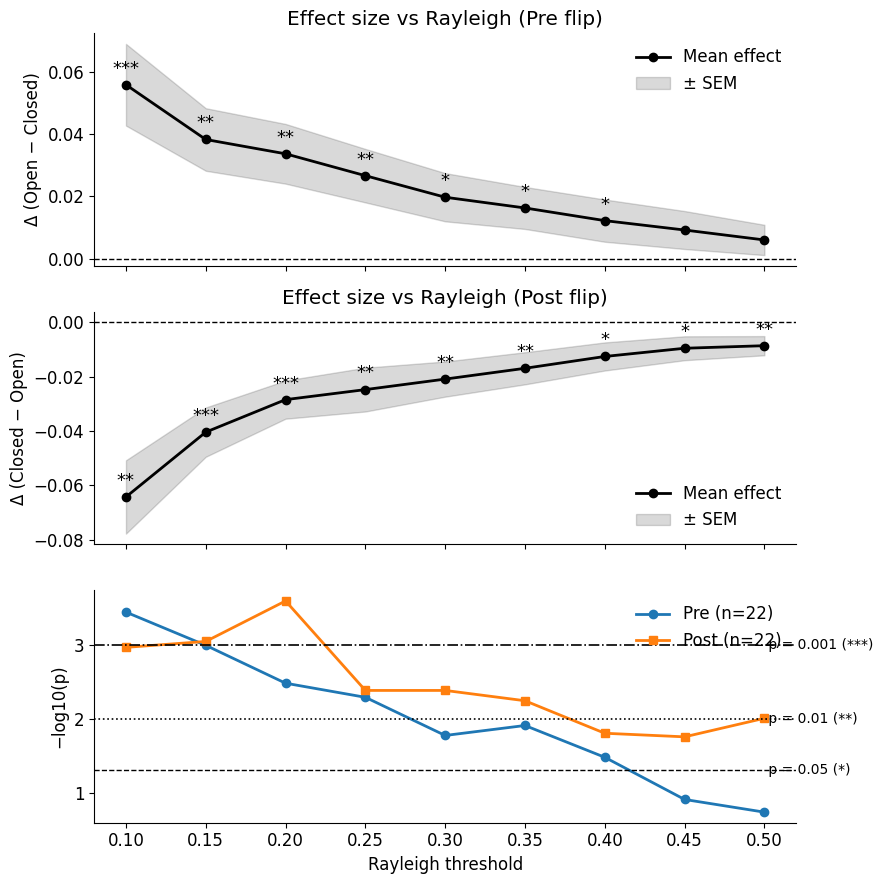

In [46]:
results_sem_df, (fig, (ax1, ax2, ax3)) = plot_rayleigh_sweep_exact2_sem(
    sweep_rayleigh,
    out_dir=dir,
    save_table=False,
    save_fig=True
)
